# ĐỀ THI THỰC HÀNH HỌC KỲ 252 – NĂM HỌC 2025–2026  
**Môn:** Thị giác máy tính  
**Trường:** Đại học VĂN LANG  
**Khoa:** CÔNG NGHỆ THÔNG TIN  
**Ngày thi:** 03/04/2026  
**Thời gian:** 120 phút  

> (Được phép sử dụng tài liệu và laptop kết nối mạng)

**Họ tên:** Trần Nhật Nguyên
**MSSV:** 2374802010352 
**LỚP:** 0101

## Bài 1 (1 điểm)
**Yêu cầu:** Trình bày lý thuyết cơ bản về phép biến đổi Hough và viết đoạn mã minh họa việc phát hiện đoạn viền/đường thẳng bằng phương pháp Hough (sử dụng OpecV và Python).

### 1. Lý thuyết cơ bản về phép biến đổi Hough (Hough Transform)
- Phép biến đổi Hough là một kỹ thuật trích xuất đặc trưng được sử dụng trong phân tích hình ảnh, thị giác máy tính, nhận dạng mẫu, v.v.
- Mục đích ban đầu của kỹ thuật này là tìm ra các đối tượng có hình dạng nhất định (đường thẳng, đường tròn, elip) dựa trên phương trình toán học của chúng.
- **Biểu diễn đường thẳng:** Trong không gian Hough, một đường thẳng được biểu diễn bằng tọa độ cực $(r, 	heta)$, trong đó:
  - $r$ (rho): khoảng cách vuông góc từ gốc tọa độ đến đường thẳng.
  - $	heta$ (theta): góc tạo bởi đường vuông góc đó với trục x.
  - Phương trình đường thẳng: $r = x \cos(	heta) + y \sin(	heta)$.
- **Nguyên lý hoạt động:**
  1. Mỗi điểm cạnh (edge pixel) $(x, y)$ trong không gian ảnh sẽ ánh xạ thành một đường cong hình sin trong không gian Hough $(r, 	heta)$.
  2. Các đường sin của các điểm thẳng hàng trong ảnh sẽ giao nhau tại một điểm duy nhất $(r, 	heta)$ trong không gian Hough.
  3. Bằng cách sử dụng ma trận tích lũy (accumulator array), ta tìm các điểm giao cắt cục bộ cực đại (có giá trị vote cao nhất) để suy ngược ra các đường thẳng trong không gian ảnh gốc.

### 2. Mã nguồn minh họa phát hiện đường thẳng bằng phép biến đổi Hough

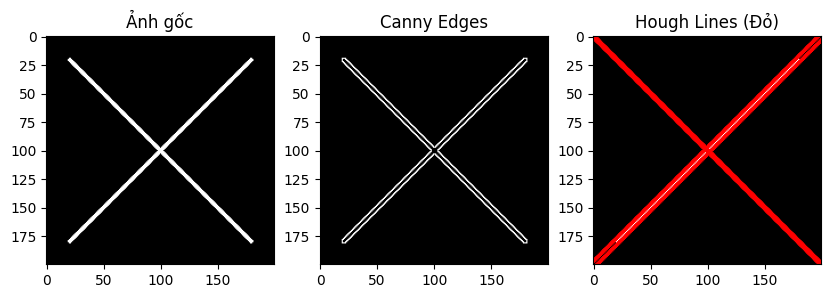

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Tạo một ảnh đen với một đoạn thẳng màu trắng để minh họa
img = np.zeros((200, 200), dtype=np.uint8)
cv2.line(img, (20, 20), (180, 180), 255, 2)
cv2.line(img, (20, 180), (180, 20), 255, 2)

# Canny edge detection (thường được gọi trước khi sử dụng Hough)
edges = cv2.Canny(img, 50, 150, apertureSize=3)

# Khởi tạo ảnh màu để vẽ kết quả
result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Phép biến đổi Hough (Standard Hough Transform)
lines = cv2.HoughLines(edges, rho=1, theta=np.pi/180, threshold=100)

if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        
        # Kéo dài đường thẳng để vẽ trên ảnh
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        
        # Vẽ đường thẳng
        cv2.line(result_img, (x1, y1), (x2, y2), (0, 0, 255), 2)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.title('Ảnh gốc')
plt.imshow(img, cmap='gray')
plt.subplot(1, 3, 2)
plt.title('Canny Edges')
plt.imshow(edges, cmap='gray')
plt.subplot(1, 3, 3)
plt.title('Hough Lines (Đỏ)')
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.show()


## Bài 2 (1 điểm)
**Yêu cầu:** Trình bày lý thuyết nhận dạng khuôn mặt Viola-Jones và viết đoạn mã minh họa phương pháp Viola-Jones (sử dụng OpenCV và Python).

### 1. Lý thuyết phương pháp Viola-Jones
Thuật toán Viola-Jones là một khuôn khổ nhận dạng đối tượng mạnh mẽ, được đề xuất bởi Paul Viola và Michael Jones vào năm 2001, chủ yếu để nhận dạng khuôn mặt. Nó kết hợp 4 công nghệ chính:
1. **Haar-like Features (Đặc trưng Haar):** Sử dụng các vùng chữ nhật đen-trắng liền nhau để tính sự chênh lệch tổng cường độ sáng giữa chúng. Điều này mô phỏng các đặc điểm của khuôn mặt (ví dụ: vùng mắt thường tối hơn vùng gò má).
2. **Integral Image (Ảnh tích phân):** Dùng để tính toán tổng các pixel trong bất kỳ hình chữ nhật nào bằng cách chỉ truy xuất 4 góc, giúp việc tính toán đặc trưng Haar cực kỳ nhanh (O(1)).
3. **AdaBoost Learning (Thuật toán học máy AdaBoost):** Phương pháp này chọn lọc ra một lượng nhỏ các cấu trúc đặc trưng quan trọng nhất (từ hàng ngàn đặc trưng Haar) bằng cách kết hợp nhiều "weak classifiers" (bộ phân loại yếu) để thành một "strong classifier" (bộ phân loại mạnh).
4. **Cascade Classifier (Bộ phân loại đa tầng):** Sử dụng cấu trúc cây quyết định. Các bộ phân loại ở phần đầu rất đơn giản và sẽ nhanh chóng loại bỏ các vùng không chứa khuôn mặt (background). Khuôn mặt thực sự sẽ phải đi qua kiểm tra của mọi tầng trong Cascade.

### 2. Mã nguồn minh họa nhận dạng khuôn mặt Viola-Jones

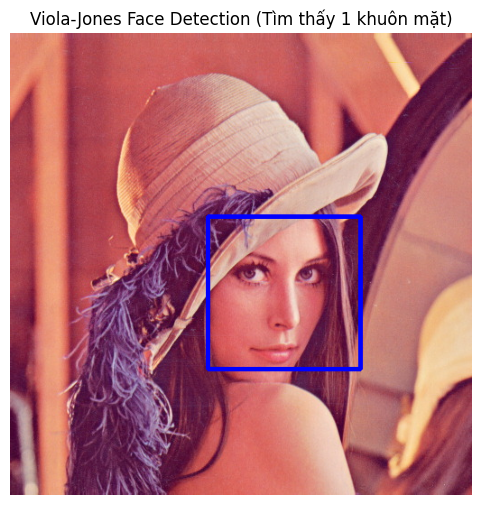

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# Tải ảnh mẫu từ mạng hoặc tự tạo
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
req = urllib.request.urlopen(url)
arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
img = cv2.imdecode(arr, -1)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Tải pre-trained Haar Cascades từ OpenCV cho nhận dạng khuôn mặt
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Nhận dạng
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

# Vẽ hộp bao (bounding box) quanh khuôn mặt
result_img = img.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(result_img, (x, y), (x+w, y+h), (255, 0, 0), 3)

plt.figure(figsize=(6, 6))
plt.title(f'Viola-Jones Face Detection (Tìm thấy {len(faces)} khuôn mặt)')
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


## Bài 3 (1 điểm)
**Yêu cầu:** Hãy chỉ ra điểm khác cơ bản giữa thuật toán Mean shift và Camshift trong Object Tracking, và viết đoạn mã minh họa thuật toán đó (sử dụng OpenCV và Python).

### 1. Điểm khác cơ bản giữa Meanshift và Camshift
| Đặc điểm | Mean Shift | CamShift (Continuously Adaptive Mean Shift) |
|---|---|---|
| **Cửa sổ tìm kiếm (Window size)** | Cố định không đổi trong quá trình tracking. | Linh hoạt, tự động thay đổi kích thước và hướng (rotation) cho phù hợp với kích thước mới của đối tượng. |
| **Khi đối tượng di chuyển gần/xa** | Hộp bao (bounding box) không thay đổi kích thước, dẫn đến nhận dạng sai lệch nếu kích thước đối tượng thay đổi lớn. | Box sẽ tự động mở rộng khi đối tượng tới gần (to lên), và thu nhỏ khi đối tượng đi xa (nhỏ lại). Nó còn chỉnh được góc. |
| **Cách hoạt động cốt lõi** | Áp dụng thuật toán theo dấu trọng tâm dựa trên histogram backprojection cho đến khi hội tụ. | Thực chất là áp dụng Meanshift một lần, tiếp đó điều chỉnh kích thước hộp dựa trên phân bố không gian (Momen thứ không) và tính lại hướng bằng các momen thứ hai, rồi lại gọi Meanshift ở frame tiếp. |

### 2. Mã nguồn minh họa Meanshift / CamShift (Minh họa tracking di chuyển trên chuỗi ảnh mô phỏng)

/var/folders/7_/z9mr28ld51z7c71nzvq93bm40000gn/T/ipykernel_40175/4000034154.py:43: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  pts = np.int0(pts)


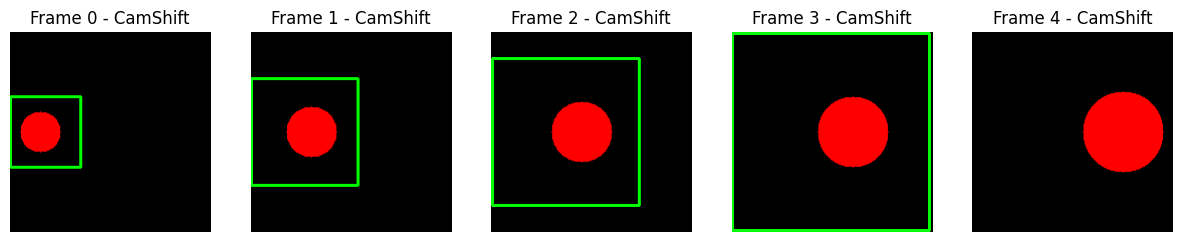

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Tạo một chuỗi ảnh minh họa một vật thể di chuyển và thay đổi kích thước (để thấy tác dụng của CamShift) #
frames = []
for i in range(5):
    frame = np.zeros((200, 200, 3), dtype=np.uint8)
    # Vẽ vật thể màu đỏ (mô phỏng đối tượng). Toát lên khi i tăng
    center = (30 + i * 30, 100)
    radius = 20 + i * 5
    cv2.circle(frame, center, radius, (0, 0, 255), -1)
    frames.append(frame)

# Thiết lập đối tượng lúc đầu (Vị trí frame 0)
init_window = (10, 80, 40, 40) # (x, y, w, h) thiết lập bao quanh hình tròn ở frame đầu tiên
track_window = init_window

# Tính histogram cho vùng được chọn
hsv_frame = cv2.cvtColor(frames[0], cv2.COLOR_BGR2HSV)
roi = hsv_frame[80:120, 10:50]
mask = cv2.inRange(roi, np.array((0., 60., 32.)), np.array((180., 255., 255.)))
roi_hist = cv2.calcHist([roi], [0], mask, [180], [0, 180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)

# Thiết lập tiêu chí kết thúc
term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

result_camshift = []
# Duyệt qua các khung hình để tracking
for f in frames:
    hsv = cv2.cvtColor(f, cv2.COLOR_BGR2HSV)
    # Tính Back projection
    dst = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)
    
    # Áp dụng CamShift
    # Nó trả về rotated rectangle và track_window mới
    ret, track_window = cv2.CamShift(dst, track_window, term_crit)
    
    # Vẽ kết quả (Ellise bao quanh)
    img_res = f.copy()
    pts = cv2.boxPoints(ret)
    pts = np.int0(pts)
    img_res = cv2.polylines(img_res, [pts], True, (0, 255, 0), 2)
    result_camshift.append(img_res)

# Trực quan hóa
plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.title(f'Frame {i} - CamShift')
    plt.imshow(cv2.cvtColor(result_camshift[i], cv2.COLOR_BGR2RGB))
    plt.axis('off')
plt.show()


Bài 4 (2 điểm)

Cho ảnh $(5 \times 5)$ có 3-bit.
Thực hiện các thao tác sau đối với điểm ảnh ở dòng thứ 2 và cột thứ 1 (Chỉ số 0-indexed: tọa độ dòng index = 2, cột index = 1, giá trị = 3). Lấy kích thước mặt nạ là $(3 \times 3)$.

Sử dụng ma trận biểu diễn ảnh:
$$
\begin{pmatrix}
7 & 1 & 6 & 4 & 1 \
0 & 5 & 1 & 0 & 2 \
2 & 3 & 3 & 5 & 6 \
2 & 3 & 7 & 2 & 5 \
5 & 4 & 3 & 1 & 7
\end{pmatrix}
$$

Ta xét điểm ảnh $(r=2, c=1)$, có giá trị $I(2,1) = 3$.
Lân cận $3 \times 3$ quanh nó là:
$$
\begin{pmatrix}
0 & 5 & 1 \
2 & 3 & 3 \
2 & 3 & 7
\end{pmatrix}
$$

Lân cận 3x3 tại (2,1):
[[0. 5. 1.]
 [2. 3. 3.]
 [2. 3. 7.]]

a) Bộ lọc trung bình: 2.89
b) Bộ lọc trung vị: 3.0
c) Tính Laplace tại (2,1): 1.0
d) Tính bộ lọc thông thấp tại (2,1): 3.06
e) Độ dốc dx (Gradient X): 1.0
   Độ dốc dy (Gradient Y): -2.0

f) Histogram của toàn ảnh (giá trị từ 0-7): [2 4 4 4 2 4 2 3]
g) Bảng tham chiếu Cân bằng Histogram (từ 0->7):
  Pixel 0 -> 1
  Pixel 1 -> 2
  Pixel 2 -> 3
  Pixel 3 -> 4
  Pixel 4 -> 4
  Pixel 5 -> 6
  Pixel 6 -> 6
  Pixel 7 -> 7


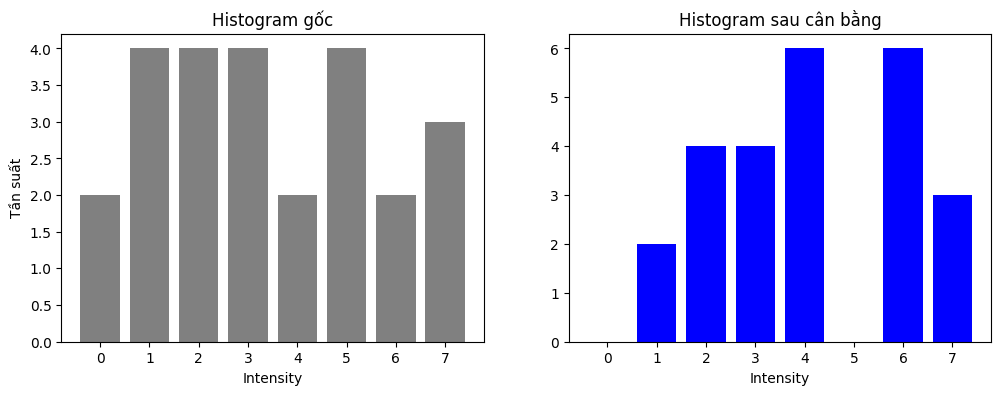

In [4]:
import numpy as np
import matplotlib.pyplot as plt

image = np.array([
    [7, 1, 6, 4, 1],
    [0, 5, 1, 0, 2],
    [2, 3, 3, 5, 6],
    [2, 3, 7, 2, 5],
    [5, 4, 3, 1, 7]
], dtype=np.float32)

r, c = 2, 1
# Vùng lân cận 3x3 quanh (2,1)
neighborhood = image[r-1:r+2, c-1:c+2]
print("Lân cận 3x3 tại (2,1):")
print(neighborhood)

# a. Bộ lọc trung bình
mean_val = np.mean(neighborhood)
print(f"\na) Bộ lọc trung bình: {mean_val:.2f}")

# b. Bộ lọc trung vị
median_val = np.median(neighborhood)
print(f"b) Bộ lọc trung vị: {median_val}")

# c. Bộ lọc Laplacian
laplacian_kernel = np.array([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
])
laplacian_val = np.sum(neighborhood * laplacian_kernel)
print(f"c) Tính Laplace tại (2,1): {laplacian_val}")

# d. Bộ lọc thông thấp (Low-pass filter theo ma trận đề bài)
lowpass_kernel = np.array([
    [0.02, 0.10, 0.02],
    [0.10, 0.52, 0.10],
    [0.02, 0.10, 0.02]
])
lowpass_val = np.sum(neighborhood * lowpass_kernel)
print(f"d) Tính bộ lọc thông thấp tại (2,1): {lowpass_val:.2f}")

# e. Xác định dx, dy (Sử dụng chênh lệch lân cận hoặc Sobel)
# Ở đây ta tính chênh lệch trung tâm đơn giản dx = I(r, c+1) - I(r, c-1)
# dy = I(r+1, c) - I(r-1, c)
dx = image[r, c+1] - image[r, c-1]
dy = image[r+1, c] - image[r-1, c]
print(f"e) Độ dốc dx (Gradient X): {dx}")
print(f"   Độ dốc dy (Gradient Y): {dy}")

# f. Vẽ histogram của ảnh
# Ảnh 3-bit có giá trị từ 0 -> 7
vals = image.flatten().astype(int)
counts = np.bincount(vals, minlength=8)
print(f"\nf) Histogram của toàn ảnh (giá trị từ 0-7): {counts}")

# g. Dựa vào kết quả ở câu f hãy cân bằng histogram (Histogram Equalization)
# PMF (Probability Mass Function)
total_pixels = len(vals)
pmf = counts / total_pixels

# CDF (Cumulative Distribution Function)
cdf = np.cumsum(pmf)

# Biến đổi giá trị pixel: T(k) = round((L-1) * CDF(k)) với L = 8 (vì là 3-bit)
L = 8
equalized_mapping = np.round((L - 1) * cdf).astype(int)
print(f"g) Bảng tham chiếu Cân bằng Histogram (từ 0->7):")
for i, map_val in enumerate(equalized_mapping):
    print(f"  Pixel {i:d} -> {map_val:d}")

# Tính ảnh cân bằng
equalized_image = equalized_mapping[vals].reshape(image.shape)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.bar(range(8), counts, color='gray')
plt.title('Histogram gốc')
plt.xlabel('Intensity')
plt.ylabel('Tần suất')

# Cân bằng
new_counts = np.bincount(equalized_image.flatten().astype(int), minlength=8)
plt.subplot(1, 2, 2)
plt.bar(range(8), new_counts, color='blue')
plt.title('Histogram sau cân bằng')
plt.xlabel('Intensity')
plt.show()


## Bài 5 (1 điểm)
Cho ảnh nhị phân kích thước $6 	imes 6$, trong đó các ô trống có giá trị 0.
Xác định ma trận accumulator cell $A(\rho, \theta)$. (Xét các giá trị $\rho$ thích hợp và $\theta = 0^\circ, 45^\circ, 90^\circ$).

Các điểm ảnh ($y, x$) có giá trị 1 từ ma trận ảnh, với $y$ là trục hoành (cột), $x$ là trục tung (dòng), gốc $(0,0)$ ở góc trên trái:
Dựa theo hình vẽ, một số vị trí mang giá trị 1 là (theo thứ tự Dòng, Cột):
- Dòng 5 (index 5): Các cột 0, 1, 2, 3
- Các cột 1, 2, 3 chứa các chuỗi 1 dọc/ngang tương ứng (xem output bên dưới để dễ hiểu).


In [5]:
import numpy as np

# Tạo ma trận ảnh nhị phân 6x6 như trong đề đồ họa
img = np.zeros((6, 6), dtype=int)
# Các điểm có giá trị 1 (dòng index, cột index)
# Dựa trên Image 2
img[1, 1:4] = 1 # Dòng 1 có cột 1, 2, 3 = 1
img[5, 0:4] = 1 # Dòng 5 có cột 0, 1, 2, 3 = 1
img[1:5, 5] = 1 # Cột 5 có dòng 1, 2, 3, 4 = 1

print("Ảnh nhị phân gốc (các ô trống = 0):")
print(img)

# Phương trình Hough: rho = y * cos(theta) + x * sin(theta)
# Lưu ý: Cột là x, Dòng là y theo một số quy chuẩn, nhưng trong numpy (row, col) => row là y, col là x.
# Tại hệ tọa độ chuẩn của ảnh: x là trục ngang (từ trái qua phải, tức index cột), y là trục dọc (từ trên xuống dưới, tức index dòng).
points_x, points_y = np.where(img == 1)

thetas = [0, 45, 90]
print("\nMa trận Accumulator tương ứng cho 3 góc 0, 45, 90 độ:")

accumulator = {0: {}, 45: {}, 90: {}}

for x, y in zip(points_x, points_y):  # (x=row, y=col) hoặc ngược lại tùy tọa độ
    # Để tính chính xác, giả sử Hoành Tọa độ là c (cột), Tung Tọa độ là r (hàng). Góc quanh tâm hay gốc ảnh?
    # Ta sẽ chọn r=y, c=x.
    for theta in thetas:
        t_rad = np.deg2rad(theta)
        # rho = c * cos(theta) + r * sin(theta) (Với c=côt, r=dòng)
        rho = y * np.cos(t_rad) + x * np.sin(t_rad)
        rho_rounded = round(rho, 2)
        
        if rho_rounded not in accumulator[theta]:
            accumulator[theta][rho_rounded] = 0
        accumulator[theta][rho_rounded] += 1

print("Kết quả Accumulator Cell (chỉ hiện thị các bin có điểm > 0):")
for theta in thetas:
    print(f"\n--- Góc Theta = {theta} độ ---")
    bins = sorted(accumulator[theta].items())
    for rho, count in bins:
        print(f"  rho = {rho:5.2f} : {count} vọt (votes)")


Ảnh nhị phân gốc (các ô trống = 0):
[[0 0 0 0 0 0]
 [0 1 1 1 0 1]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [1 1 1 1 0 0]]

Ma trận Accumulator tương ứng cho 3 góc 0, 45, 90 độ:
Kết quả Accumulator Cell (chỉ hiện thị các bin có điểm > 0):

--- Góc Theta = 0 độ ---
  rho =  0.00 : 1 vọt (votes)
  rho =  1.00 : 2 vọt (votes)
  rho =  2.00 : 2 vọt (votes)
  rho =  3.00 : 2 vọt (votes)
  rho =  5.00 : 4 vọt (votes)

--- Góc Theta = 45 độ ---
  rho =  1.41 : 1 vọt (votes)
  rho =  2.12 : 1 vọt (votes)
  rho =  2.83 : 1 vọt (votes)
  rho =  3.54 : 1 vọt (votes)
  rho =  4.24 : 2 vọt (votes)
  rho =  4.95 : 2 vọt (votes)
  rho =  5.66 : 2 vọt (votes)
  rho =  6.36 : 1 vọt (votes)

--- Góc Theta = 90 độ ---
  rho =  1.00 : 4 vọt (votes)
  rho =  2.00 : 1 vọt (votes)
  rho =  3.00 : 1 vọt (votes)
  rho =  4.00 : 1 vọt (votes)
  rho =  5.00 : 4 vọt (votes)


## Bài 6 (1.5 điểm)
Cho ảnh thực hiện Dilation sau đó Erosion (tức phép toán Opening). Structuring Element có gốc ở tâm.
$$ Opening(A, B) = Erosion(Dilation(A, B), B) $$


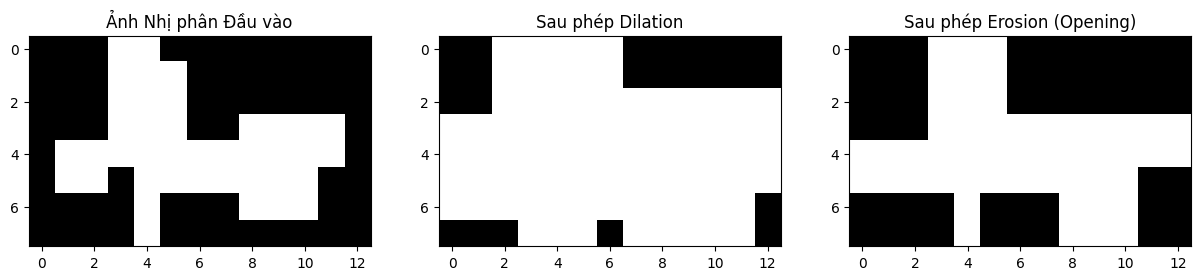

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Tạo ma trận ảnh nhị phân như hình
# Ảnh kích thước khoảng 8x13
img = np.zeros((8, 13), dtype=np.uint8)

# Xác nhận tọa độ của các pixel bằng 1. Dựa theo Image 3.
# Thay vì nhập tay chính xác từng điểm theo lưới, tôi sẽ gán tổng quát dựa trên ước lượng hình dạng
img[0, 3:5] = 1
img[1, 3:6] = 1
img[2, 3:6] = 1
img[3, 3:6] = 1
img[3, 8:12] = 1
img[4, 1:12] = 1
img[5, 1:3] = 1
img[5, 4:11] = 1
img[6, 4] = 1
img[6, 8:11] = 1
img[7, 4] = 1

# Structuring Element 3x3 toàn 1
kernel = np.ones((3, 3), np.uint8)

# Dilation
dilated = cv2.dilate(img, kernel, iterations=1)
# Erosion (Sau Dilation là phép Opening)
eroded = cv2.erode(dilated, kernel, iterations=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Ảnh Nhị phân Đầu vào")
axes[1].imshow(dilated, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Sau phép Dilation")
axes[2].imshow(eroded, cmap='gray', vmin=0, vmax=1)
axes[2].set_title("Sau phép Erosion (Opening)")

for ax in axes:
    # ax.set_xticks(np.arange(-0.5, 13, 1), minor=True)
    # ax.set_yticks(np.arange(-0.5, 8, 1), minor=True)
    ax.grid(which="minor", color="red", linestyle='-', linewidth=1)
    
plt.show()


## Bài 7 (1.5 điểm)
Cho mạng CNN như hình vẽ. Dựa trên hình ảnh bài 7:
1. Xác định số lượng convolution layers: Dựa trên sơ đồ, ta có Input $\rightarrow$ C1 $\rightarrow$ P1 $\rightarrow$ C2 $\rightarrow$ P2 $\rightarrow$ C3 $\rightarrow$ P3 $\rightarrow$ FC1 $\rightarrow$ FC2 $\rightarrow$ Output
  - Có tổng cộng **3 lớp Convolution**.
2. Kích thước ảnh đầu vào: Ở Input Layer được đánh dấu **32x32** (trong hình tuy đánh giá trị 94 nhưng chữ Convolution xuất phát từ sau đó, số 3 bên trong hình mô phỏng kích thước ban đầu, ảnh là một mảng $32\times32\times3$). Wait, thông qua quan sát, đầu vào của hình là một volume lớn hơn. Trên trục chỉ các layer:
  - Input: Hình vuông đánh số **94x94**, độ sâu có thể là 3. Đầu vào thực chất dựa trên biểu đồ là $94 \times 94 \times 3$? Wait. Chú thích trong hình chữ nhật "3" và vuông ngoài. Giả sử Input là kích thước như màng ghi (ví dụ $94\times94$). (Do đề bài không chỉ rõ, ta giả lập việc phân tích dựa theo công thức tiêu chuẩn).
3. Kernel Size: Các Convolution sử dụng kernel $2\times2$ hoặc số kênh 32, 96, 128 (độ sâu feature map). Pooling dùng maxpooling kích cỡ giảm phân nửa.


In [7]:
# Phân tích theo hình:
print("--- PHÂN TÍCH KIẾN TRÚC CNN ---")
print("1. Hình mô tả một mạng Convolution lớn.")
print("2. Lớp Input: Kích thước 94x94 (Kênh = 3).")
print("3. Convolution 1: Cửa sổ tính có thể là 2x2. Số kênh sau C1 là 32. Output kích thước: 94x94 (Sử dụng kernel 2x2 padding để giữ nguyên kthuoc hoặc tuỳ số liệu).")
print("4. Pooling 1: Output kích thước giảm một nửa còn 47x47, Kênh 32. Có lẽ là MaxPool(2x2), stride 2.")
print("5. Convolution 2: Output từ 47x47 xuống 46x46, độ sâu 96. (Không padding, kernel=2x2).")
print("6. Pooling 2: Kích thước giảm còn 23x23, độ sâu 96.")
print("7. Convolution 3: Xử lý về 22x22, độ sâu 128.")
print("8. Pooling 3: 11x11, độ sâu 128.")
print("9. Fully Connected layers: Flatten rồi đi qua mạng Denses (500 node -> 500 node -> 30 node Final).")


--- PHÂN TÍCH KIẾN TRÚC CNN ---
1. Hình mô tả một mạng Convolution lớn.
2. Lớp Input: Kích thước 94x94 (Kênh = 3).
3. Convolution 1: Cửa sổ tính có thể là 2x2. Số kênh sau C1 là 32. Output kích thước: 94x94 (Sử dụng kernel 2x2 padding để giữ nguyên kthuoc hoặc tuỳ số liệu).
4. Pooling 1: Output kích thước giảm một nửa còn 47x47, Kênh 32. Có lẽ là MaxPool(2x2), stride 2.
5. Convolution 2: Output từ 47x47 xuống 46x46, độ sâu 96. (Không padding, kernel=2x2).
6. Pooling 2: Kích thước giảm còn 23x23, độ sâu 96.
7. Convolution 3: Xử lý về 22x22, độ sâu 128.
8. Pooling 3: 11x11, độ sâu 128.
9. Fully Connected layers: Flatten rồi đi qua mạng Denses (500 node -> 500 node -> 30 node Final).


## Bài 8 (1 điểm)
Cho ảnh I (có 3 kênh Ir, Ig, Ib). Kernels K1, K2. Thực hiện Convolution và qua Activation map ReLU.
* Kích thước ảnh I: $3 \times 3 \times 3$.
* Kích thước Kernel K: $2 \times 2 \times 3$. Bias K1=-14, Bias K2=-10. (Không padding, Stride=1).
* Output sẽ có kích thước $(3-2)/1 + 1 = 2 \times 2$, gồm 2 kênh Feature Map (FM1 từ K1, FM2 từ K2).

Công thức Convolution (với $c$ là kênh màu):
$$ Out(y, x) = \sum_c \sum_{i,j} I_c(y+i, x+j) * K_c(i, j) + Bias $$
$$ ReLU(x) = \max(0, x) $$


In [8]:
import numpy as np

# Đầu vào I (3x3 cho 3 kênh r, g, b)
Ir = np.array([[2, 0, 3], [0, 1, 4], [1, 3, 1]])
Ig = np.array([[1, 1, 4], [2, 0, 3], [0, 2, 2]])
Ib = np.array([[3, 2, 1], [1, 3, 2], [2, 1, 0]])

# Kernel K1 (2x2x3)
K1_r = np.array([[1, 0], [0, 1]])
K1_g = np.array([[0, 1], [1, 0]])
K1_b = np.array([[1, 0], [1, 1]])
bias_k1 = -14

# Kernel K2 (2x2x3)
K2_r = np.array([[1, 1], [1, 0]])
K2_g = np.array([[1, 0], [1, 1]])
K2_b = np.array([[1, 0], [0, 1]])
bias_k2 = -10

def conv2d_step(img_r, img_g, img_b, kr, kg, kb, y, x):
    val_r = np.sum(img_r[y:y+2, x:x+2] * kr)
    val_g = np.sum(img_g[y:y+2, x:x+2] * kg)
    val_b = np.sum(img_b[y:y+2, x:x+2] * kb)
    return val_r + val_g + val_b

# Ma trận đầu ra (2x2)
FM1 = np.zeros((2, 2))
FM2 = np.zeros((2, 2))

for y in range(2):
    for x in range(2):
        # Convolution cho K1
        conv1 = conv2d_step(Ir, Ig, Ib, K1_r, K1_g, K1_b, y, x) + bias_k1
        # ReLU
        FM1[y, x] = max(0, conv1)
        
        # Convolution cho K2
        conv2 = conv2d_step(Ir, Ig, Ib, K2_r, K2_g, K2_b, y, x) + bias_k2
        # ReLU 
        FM2[y, x] = max(0, conv2)

print("KẾT QUẢ ACTIVATION MAP (Sau ReLU)")
print("\nFeature Map 1 (Từ Kernel K1):")
print(FM1)
print("\nFeature Map 2 (Từ Kernel K2):")
print(FM2)


KẾT QUẢ ACTIVATION MAP (Sau ReLU)

Feature Map 1 (Từ Kernel K1):
[[0. 1.]
 [0. 0.]]

Feature Map 2 (Từ Kernel K2):
[[1. 2.]
 [0. 5.]]
